In [11]:
import warnings
warnings.filterwarnings("ignore")

In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image


In [13]:
train_dir     ='/kaggle/input/teeth-dataset-cellula/Teeth_Dataset/Training'
validation_dir='/kaggle/input/teeth-dataset-cellula/Teeth_Dataset/Validation'

In [14]:
train_classes = os.listdir(train_dir)
validation_classes = os.listdir(validation_dir)
print(" TRAIN Classes:", train_classes)
print(" VAL Classes:", validation_classes)


 TRAIN Classes: ['OC', 'CaS', 'OT', 'CoS', 'Gum', 'MC', 'OLP']
 VAL Classes: ['OC', 'CaS', 'OT', 'CoS', 'Gum', 'MC', 'OLP']


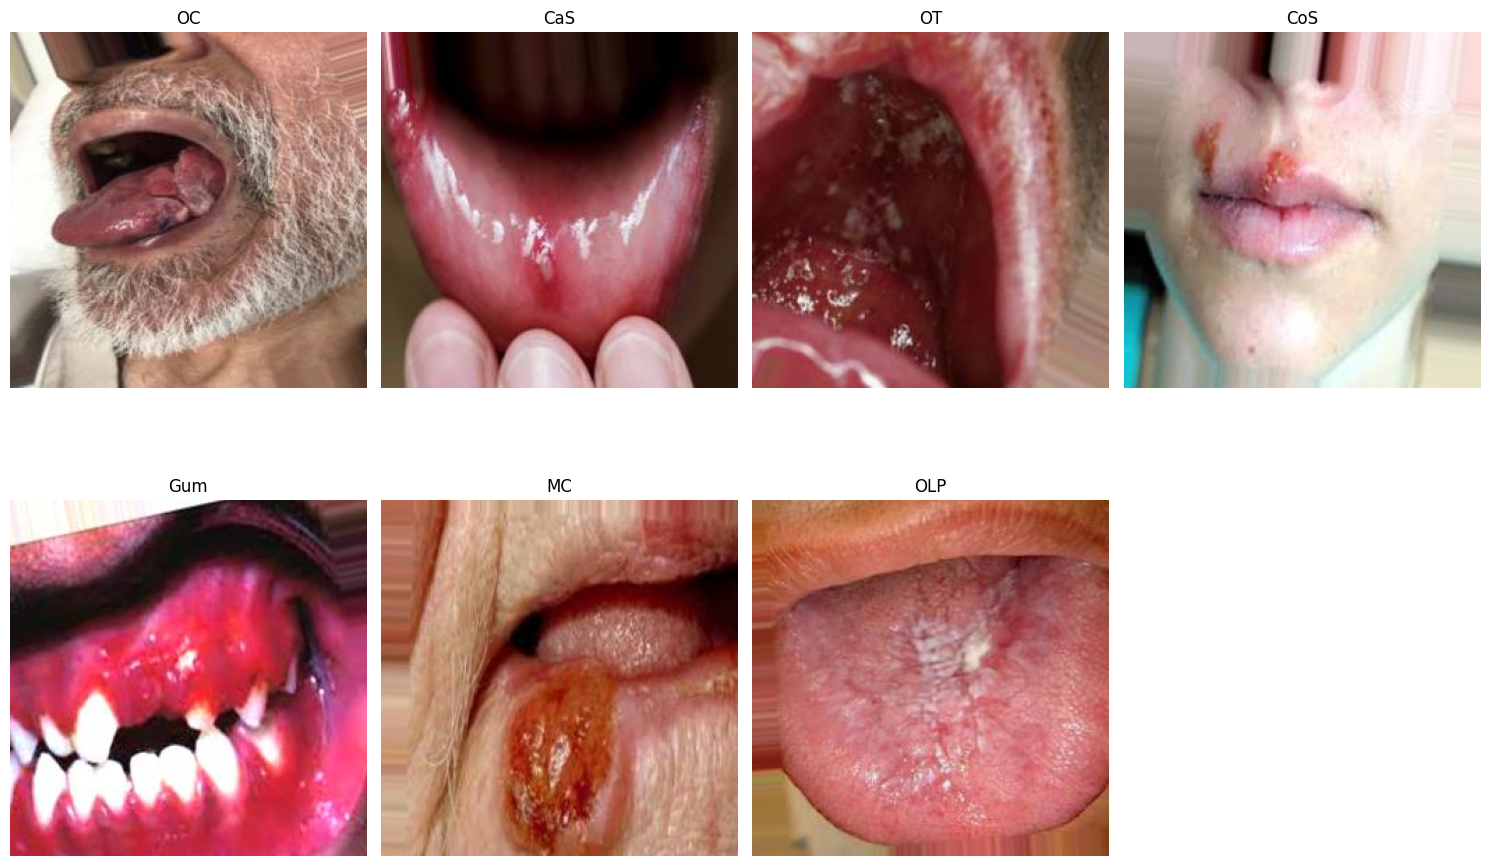

In [15]:
import glob
import random
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(15,10))

for i, cls in enumerate(train_classes):
    # Get all images in the class
    img_list = glob.glob(f"{train_dir}/{cls}/*")
      # Choose a random image
    img_path = random.choice(img_list)
    
    img = Image.open(img_path)
    
    plt.subplot(2, 4, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [16]:
# Count the number of images per class
train_counts = {cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in train_classes}

# Total number of images
total_images = sum(train_counts.values())

print("Total images in Training set:", total_images)
print("\nNumber of images per class:")
for cls, count in train_counts.items():
    print(f"{cls}: {count}")


Total images in Training set: 3087

Number of images per class:
OC: 324
CaS: 480
OT: 393
CoS: 450
Gum: 360
MC: 540
OLP: 540


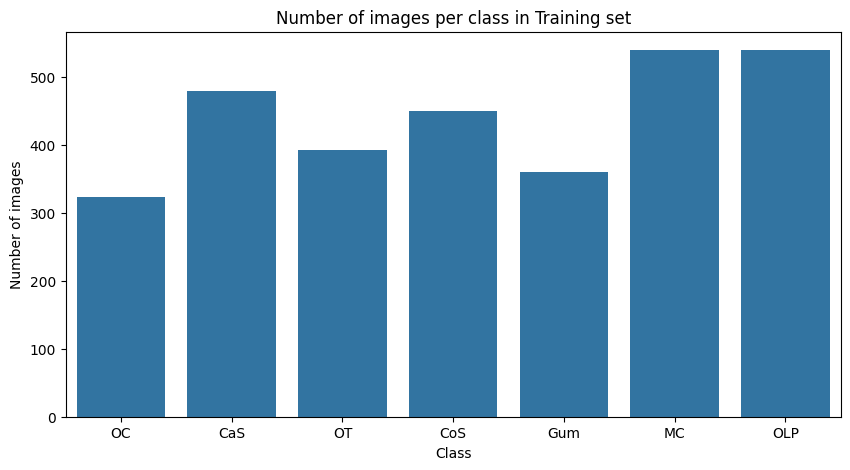

In [17]:
plt.figure(figsize=(10,5))
sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()))
plt.title('Number of images per class in Training set')
plt.ylabel('Number of images')
plt.xlabel('Class')
plt.xticks()
plt.show()

In [18]:
from PIL import Image
import glob

# To check image type / modes
sizes = set()
modes = set()  

for cls in train_classes:
    for img_path in glob.glob(f"{train_dir}/{cls}/*"):
        img = Image.open(img_path)
        sizes.add(img.size)   # (width, height)
        modes.add(img.mode)   # Image type: "RGB", "L", "RGBA", ...

# Check image sizes
if len(sizes) == 1:
    print("All images have the same size:", sizes.pop())
else:
    print("Images have different sizes:", sizes)

# Check number of  modes
if len(modes) == 1:
    print("All images have the same mode:", modes.pop())
else:
    print("Images have different modes:", modes)


All images have the same size: (256, 256)
Images have different modes: {'CMYK', 'RGB'}


In [19]:
from PIL import Image
import glob

cmyk_count = 0  # Counter for CMYK images

for cls in train_classes:
    for img_path in glob.glob(f"{train_dir}/{cls}/*"):
        img = Image.open(img_path)
        if img.mode == 'CMYK':
            cmyk_count += 1

print("Number of CMYK images:", cmyk_count)


Number of CMYK images: 1


CMYK image found: /kaggle/input/teeth-dataset-cellula/Teeth_Dataset/Training/Gum/g_1207.jpg


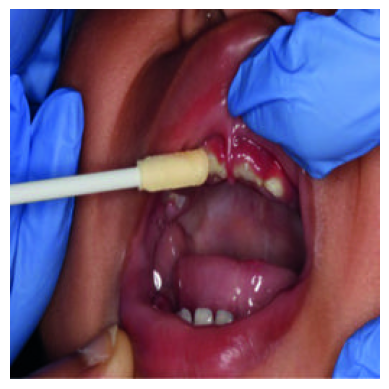

In [20]:
from PIL import Image
import glob
import matplotlib.pyplot as plt

# Search for a CMYK image
for cls in train_classes:
    for img_path in glob.glob(f"{train_dir}/{cls}/*"):
        img = Image.open(img_path)
        if img.mode == 'CMYK':
            print("CMYK image found:", img_path)
           # Display the image
            plt.imshow(img.convert('RGB')) # Temporary conversion for display
            plt.axis('off')
            plt.show()
            break    # Stop searching after displaying the image

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

from tensorflow.keras.preprocessing import image_dataset_from_directory


In [25]:
ds_train = image_dataset_from_directory(
    train_dir,
    image_size=(256, 256),  
    batch_size=32,
    label_mode='categorical', 
    shuffle=True
)


Found 3087 files belonging to 7 classes.


In [26]:
ds_val = image_dataset_from_directory(
    validation_dir,
    image_size=(256, 256),
    batch_size=32,
    label_mode='categorical',
    shuffle=False
)


Found 1028 files belonging to 7 classes.


In [27]:
import tensorflow as tf

def normalize_and_convert(image, label):
    # Convert image to float32 [0,1]
    image = tf.image.convert_image_dtype(image, tf.float32)
   # Force 3 channels → convert any CMYK or grayscale image to RGB

    image = tf.image.resize(image, [256, 256])
    if image.shape[-1] != 3:
        image = tf.image.grayscale_to_rgb(image)
    return image, label

AUTOTUNE = tf.data.AUTOTUNE



ds_train = ds_train.map(normalize_and_convert, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
ds_val   = ds_val.map(normalize_and_convert, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)


# التجربة الثانيه 

In [29]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

# ======== 1️⃣ Residual Block ========
def residual_block(x, filters, stride=1):
    shortcut = x
    # First Conv
    x = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False,
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Second Conv
    x = layers.Conv2D(filters, 3, strides=1, padding='same', use_bias=False,
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)

    # Adjust shortcut if dimensions change
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, use_bias=False,
                                 kernel_regularizer=regularizers.l2(1e-4))(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x

# ======== 2️⃣ Build ResNet-18 with Augmentation Layers ========
def build_resnet18_aug(input_shape=(256, 256, 3), num_classes=7):
    inputs = layers.Input(shape=input_shape)
    
    # ===== Data Augmentation inside the model =====
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.2)(x)
    x = layers.RandomZoom(0.2)(x)
    x = layers.RandomContrast(0.2)(x)

    # ===== Initial Conv + MaxPooling =====
    x = layers.Conv2D(64, 7, strides=2, padding='same', use_bias=False,
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)

    # conv2_x
    x = residual_block(x, 64)
    x = residual_block(x, 64)

    # conv3_x
    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128)

    # conv4_x
    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 256)

    # conv5_x
    x = residual_block(x, 512, stride=2)
    x = residual_block(x, 512)

    # Global Average Pooling + Dropout + Output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax',
                           kernel_regularizer=regularizers.l2(1e-4))(x)

    return models.Model(inputs, outputs, name="ResNet18_Augmented")


In [30]:
# ======== 3️⃣ Prepare the model ========
num_classes = 7  # replace with your actual number of classes
model = build_resnet18_aug(input_shape=(256, 256, 3), num_classes=num_classes)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ======== 4️⃣ Callbacks ========
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model.h5', monitor='val_accuracy', save_best_only=True
)

# ======== 5️⃣ Train the model ========
# Suppose you have ds_train_images, ds_train_labels, ds_val_images, ds_val_labels
# in numpy arrays or tf.data datasets

In [32]:
history = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=50,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/50


I0000 00:00:1770404847.261678     137 cuda_dnn.cc:529] Loaded cuDNN version 91002


97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.1980 - loss: 3.1564

97/97 ━━━━━━━━━━━━━━━━━━━━ 32s 168ms/step - accuracy: 0.1984 - loss: 3.1520 - val_accuracy: 0.1177 - val_loss: 13.4958
Epoch 2/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.3191 - loss: 2.3161

97/97 ━━━━━━━━━━━━━━━━━━━━ 14s 140ms/step - accuracy: 0.3194 - loss: 2.3152 - val_accuracy: 0.2189 - val_loss: 3.7450
Epoch 3/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 135ms/step - accuracy: 0.3455 - loss: 2.1810 - val_accuracy: 0.1333 - val_loss: 4.5305
Epoch 4/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.3940 - loss: 2.0566

...

97/97 ━━━━━━━━━━━━━━━━━━━━ 14s 140ms/step - accuracy: 0.4313 - loss: 1.8969 - val_accuracy: 0.4903 - val_loss: 1.7771
Epoch 8/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 135ms/step - accuracy: 0.4998 - loss: 1.7340 - val_accuracy: 0.2237 - val_loss: 3.1111
Epoch 9/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 135ms/step - accuracy: 0.4860 - loss: 1.6821 - val_accuracy: 0.4300 - val_loss: 1.8703
Epoch 10/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 135ms/step - accuracy: 0.5108 - loss: 1.6614 - val_accuracy: 0.4757 - val_loss: 1.7766
Epoch 11/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.5276 - loss: 1.5946

97/97 ━━━━━━━━━━━━━━━━━━━━ 14s 140ms/step - accuracy: 0.5277 - loss: 1.5943 - val_accuracy: 0.5029 - val_loss: 1.7042
Epoch 12/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 135ms/step - accuracy: 0.5802 - loss: 1.4978 - val_accuracy: 0.2704 - val_loss: 3.4710
Epoch 13/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 134ms/step - accuracy: 0.5835 - loss: 1.4477 - val_accuracy: 0.4027 - val_loss: 2.2913
Epoch 14/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 134ms/step - accuracy: 0.6061 - loss: 1.4015 - val_accuracy: 0.3424 - val_loss: 2.2474
Epoch 15/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 135ms/step - accuracy: 0.5918 - loss: 1.3885 - val_accuracy: 0.3823 - val_loss: 2.4541
Epoch 16/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.6239 - loss: 1.3417

97/97 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - accuracy: 0.6239 - loss: 1.3415 - val_accuracy: 0.5759 - val_loss: 1.5259
Epoch 17/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 134ms/step - accuracy: 0.6502 - loss: 1.2875 - val_accuracy: 0.3891 - val_loss: 2.2947
Epoch 18/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 135ms/step - accuracy: 0.6562 - loss: 1.2713 - val_accuracy: 0.4621 - val_loss: 1.9606
Epoch 19/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 134ms/step - accuracy: 0.6525 - loss: 1.2865 - val_accuracy: 0.3589 - val_loss: 3.7323
Epoch 20/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.6635 - loss: 1.2260

97/97 ━━━━━━━━━━━━━━━━━━━━ 14s 140ms/step - accuracy: 0.6636 - loss: 1.2258 - val_accuracy: 0.6031 - val_loss: 1.4249
Epoch 21/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.6981 - loss: 1.1750

97/97 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - accuracy: 0.6981 - loss: 1.1750 - val_accuracy: 0.7442 - val_loss: 1.0916
Epoch 22/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 135ms/step - accuracy: 0.7102 - loss: 1.1681 - val_accuracy: 0.5370 - val_loss: 1.8304
Epoch 23/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 135ms/step - accuracy: 0.7174 - loss: 1.1395 - val_accuracy: 0.3969 - val_loss: 2.6999
Epoch 24/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 135ms/step - accuracy: 0.7213 - loss: 1.1048 - val_accuracy: 0.6070 - val_loss: 1.5786
Epoch 25/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 134ms/step - accuracy: 0.7301 - loss: 1.0755 - val_accuracy: 0.6897 - val_loss: 1.2791
Epoch 26/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 135ms/step - accuracy: 0.7434 - loss: 1.0430 - val_accuracy: 0.6420 - val_loss: 1.3240


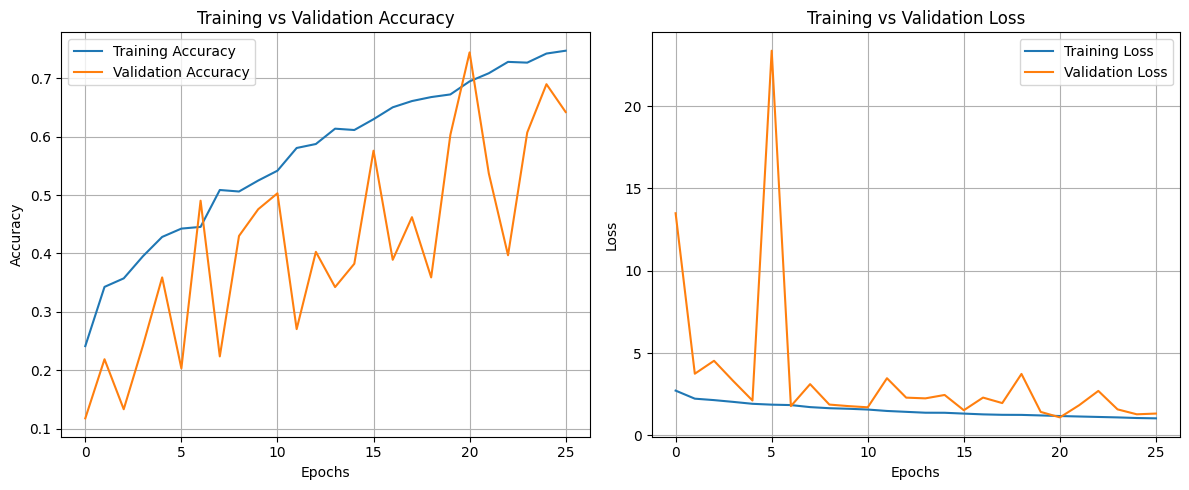

In [33]:
import matplotlib.pyplot as plt

# رسم Training و Validation Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# رسم Training و Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [34]:
model.summary()

Model: "ResNet18_Augmented"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip         │ (None, 256, 256,  │          0 │ input_layer[0][0] │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation     │ (None, 256, 256,  │          0 │ random_flip[0][0] │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom         │ (None, 256, 256,  │          0 │ random_rotation[… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_contrast     │ (None, 256, 256,  │          0 │ random_zoom[0][0] │
│ (RandomContrast)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      9,408 │ random_contrast[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     36,864 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     36,864 │ re_lu_1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 64, 64,    │          0 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,864 │ re_lu_2[0][0]   

 Total params: 33,549,911 (127.98 MB)

 Trainable params: 11,180,103 (42.65 MB)

 Non-trainable params: 9,600 (37.50 KB)

 Optimizer params: 22,360,208 (85.30 MB)

In [28]:
from tensorflow.keras import layers, models

# ======== 1️⃣ Define the basic block for ResNet-18 ========
def residual_block(x, filters, stride=1):
    shortcut = x
    # First convolution
    x = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Second convolution
    x = layers.Conv2D(filters, 3, strides=1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    # Adjust shortcut if dimensions change
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # Add shortcut to main path
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x

# ======== 2️⃣ Build the ResNet-18 model ========
def build_resnet18(input_shape=(256, 256, 3), num_classes=7):
    inputs = layers.Input(shape=input_shape)
    
    # Initial convolution + MaxPooling
    x = layers.Conv2D(64, 7, strides=2, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)

    # conv2_x
    x = residual_block(x, 64)
    x = residual_block(x, 64)

    # conv3_x
    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128)

    # conv4_x
    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 256)

    # conv5_x
    x = residual_block(x, 512, stride=2)
    x = residual_block(x, 512)

    # Global Average Pooling + Output layer
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs, name="ResNet18")






In [18]:
#  Prepare the model 
num_classes = ds_train.element_spec[1].shape[1]  # Number of classes
model = build_resnet18(input_shape=(256, 256, 3), num_classes=num_classes)

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-2),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [19]:
model.summary()

Model: "ResNet18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 128, 128,  │      9,408 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_17 (ReLU)     │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ re_lu_17[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 64, 64,    │     36,864 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_18 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 64, 64,    │     36,864 │ re_lu_18[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_19 (ReLU)     │ (None, 64, 64,    │          0 │ add_8[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 64, 64,    │     36,864 │ re_lu_19[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_23[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_20 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 64, 64,    │     36,864 │ re_lu_20[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_24[0][0] 

 Total params: 11,189,703 (42.69 MB)

 Trainable params: 11,180,103 (42.65 MB)

 Non-trainable params: 9,600 (37.50 KB)

In [20]:
#  Train the model 
history = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=20
)


Epoch 1/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 31s 170ms/step - accuracy: 0.1861 - loss: 3.1198 - val_accuracy: 0.1508 - val_loss: 85.0610
Epoch 2/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.2917 - loss: 1.8523 - val_accuracy: 0.2403 - val_loss: 3.9137
Epoch 3/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.3245 - loss: 1.7400 - val_accuracy: 0.2072 - val_loss: 3.1148
Epoch 4/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.3478 - loss: 1.6378 - val_accuracy: 0.3833 - val_loss: 1.6743
Epoch 5/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.3973 - loss: 1.5370 - val_accuracy: 0.4066 - val_loss: 1.7481
Epoch 6/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.4561 - loss: 1.4379 - val_accuracy: 0.3327 - val_loss: 1.9756
Epoch 7/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.4841 - loss: 1.3293 - val_accuracy: 0.4193 - val_loss: 1.6977
Epoch 8/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.5435 - loss: 1.2192 - val_accuracy: 0.3648 